# Video Game Sales Analysis Project
## Project Overview

In this project, I analyzed video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, I extracted insights to inform the design of future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Imported all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

## Step 1: Loaded and Started Initial Data Exploration

First, I loaded our dataset and examined its basic properties:

In [2]:
# Loaded the dataset

df = pd.read_csv('/datasets/games.csv')

In [3]:
# Displayed basic information about the dataset

print(df.info())
print(df.sample(3, random_state = 2189))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                                     Name Platform  Year_of_Release  \
5086   Phantasy Star Portable 2: Infinity      PSP           2011.0   
15684                  Garfield Gets Real       DS           2009.0   
9024                   

In [4]:
# Checked for duplicate entries

print(f'There are {df.duplicated().sum()} duplicate rows in this dataset.')


There are 0 duplicate rows in this dataset.


### Key Observations

- The dataset contains 16,715 records.
- Columns contain a mix of numeric and object data types.
- Several columns contain missing values: `name`, `year_of_release`, `genre`, `critic_score`, `user_score`, and `rating`.
- The largest missing-value issues are in the review score and rating columns.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Converted column names to lowercase

df.columns = df.columns.str.lower()

In [6]:
# Verified the changes

print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### 2.2 Data Type Conversion

In [7]:
# Checked current data types
df.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [8]:
# Made changes to data types where necessary

df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce').astype('Int64')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce').astype('Int64')

# 

df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')


# Checked current data types
print(df.dtypes)

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score         Int64
user_score         float64
rating              object
dtype: object


#### Summary:
- `year_of_release` represents four-digit calendar years, so I converted it from float to integer.
- `critic_score` represents whole-number critic ratings with a maximum value of 100, so I converted it from float to integer.
- `user_score` represents decimal user ratings with a maximum value of 10, so it should be stored as a float.
- Some `user_score` values were listed as `"tbd"`, meaning the score was not available yet. I treated these as missing values because they are not meaningfully different from existing missing `user_score` values for this analysis.
- I replaced `"tbd"` values in `user_score` with `NaN`, then converted the column to a numeric float type.

### 2.3 Handling Missing Values

In [9]:
# Examined missing values after type conversion

df.isna().sum().sort_values(ascending=False)

user_score         9125
critic_score       8578
rating             6766
year_of_release     269
name                  2
genre                 2
platform              0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64

In [10]:
# Calculate percentage of missing values

missing_percent = df.isna().mean().mul(100).round(2)
print(missing_percent.sort_values(ascending=False))

user_score         54.59
critic_score       51.32
rating             40.48
year_of_release     1.61
name                0.01
genre               0.01
platform            0.00
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
dtype: float64


- Zoomed in on these percentages, by focusing specifically on `user_score` values

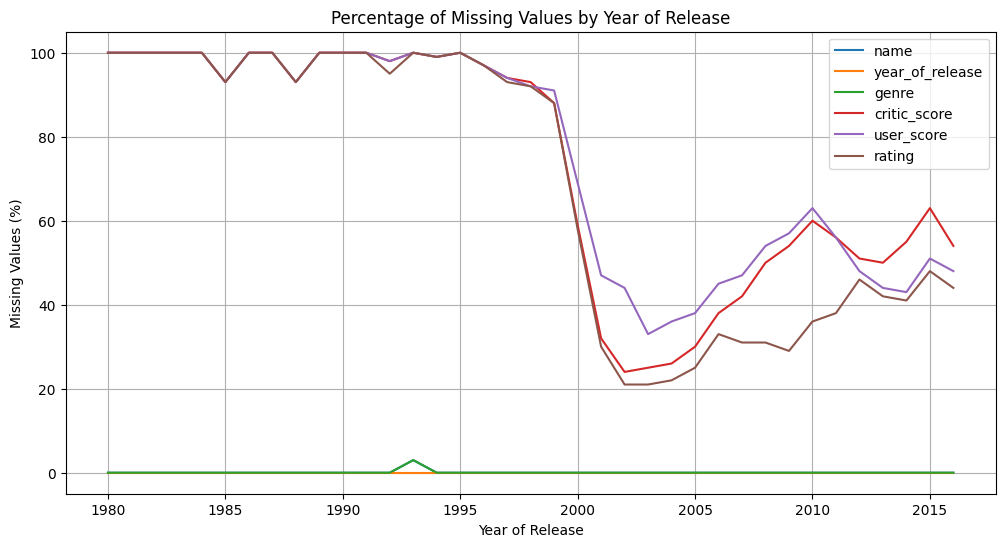

In [11]:
# Identified columns that contain missing values
# This limits the visualization to only relevant variables

cols_with_missing = df.columns[df.isna().any()]

# Calculated percentage of missing values using sum instead of mean
# sum() counts missing values, then we divide by total rows per year

missing_percent_by_year = (
    df[cols_with_missing]
    .isna()
    .groupby(df['year_of_release'])
    .sum()
    .div(df.groupby('year_of_release').size(), axis=0)
    .mul(100)
    .round(0)
)

# Displayed missing-value percentages by year as a line chart
# to compare patterns across variables over time

missing_percent_by_year.plot(
    figsize=(12, 6),
    title='Percentage of Missing Values by Year of Release',
    xlabel='Year of Release',
    ylabel='Missing Values (%)',
    grid=True
);

plt.show()

### Missing Values by Year of Release

Missing values for `critic_score`, `user_score`, and `rating` are highest before 2000, then decrease sharply afterward. This shows a clear pattern, suggesting that missing values are likely correlated with the year of release rather than being random.

This likely reflects the fact that review scores and ESRB ratings were not consistently available for older games.

The `name`, `genre`, and `year_of_release` columns have very little missing data, so they are not a major concern.

Overall, missing data is mostly connected to the age of the game and the availability of review and rating systems over time.

In [12]:
# Handled missing values based on analysis
# Removed rows with missing 'name' or 'genre' because they are few and cannot be meaningfully analyzed

df = df.dropna(subset=['name', 'genre'])

# Replaced missing ESRB ratings with 'Unknown' to retain rows for regional analysis

df['rating'] = df['rating'].fillna('Unknown')

# Left missing values in 'year_of_release', 'critic_score', and 'user_score' unchanged
# because imputing them would introduce bias and distort analysis

print(df.isna().sum().sort_values(ascending=False))

user_score         9123
critic_score       8576
year_of_release     269
name                  0
platform              0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
rating                0
dtype: int64


### Missing Values: Causes and Handling Decisions

Missing values are not random and show a clear relationship with the year of release. Earlier games are much more likely to lack `critic_score`, `user_score`, and `rating`, likely because formal review systems and ESRB ratings were not yet widely established.

Missing review scores may also occur when games did not receive enough coverage or user engagement to generate reliable scores.

Rows with missing `name` or `genre` were removed because they are few and cannot be meaningfully analyzed.

Missing values in `rating` were replaced with `"Unknown"` to preserve those records for analysis without introducing false assumptions.

Missing values in `year_of_release`, `critic_score`, and `user_score` were left unchanged, as filling them would introduce bias and distort the analysis.

### 2.4 Calculate Total Sales

In [13]:
# Calculated total global sales by summing regional sales columns
# This creates a single metric for overall performance of each game

df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

# Checked my work

print(df[['name', 'total_sales']].head())

                       name  total_sales
0                Wii Sports        82.54
1         Super Mario Bros.        40.24
2            Mario Kart Wii        35.52
3         Wii Sports Resort        32.77
4  Pokemon Red/Pokemon Blue        31.38


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
First, I examined the distribution of game releases across different years to understand the dataset's coverage.

In [14]:
# Counted the number of games released each year
# This helps assess whether all time periods have sufficient data for analysis

games_per_year = df.groupby('year_of_release').size()

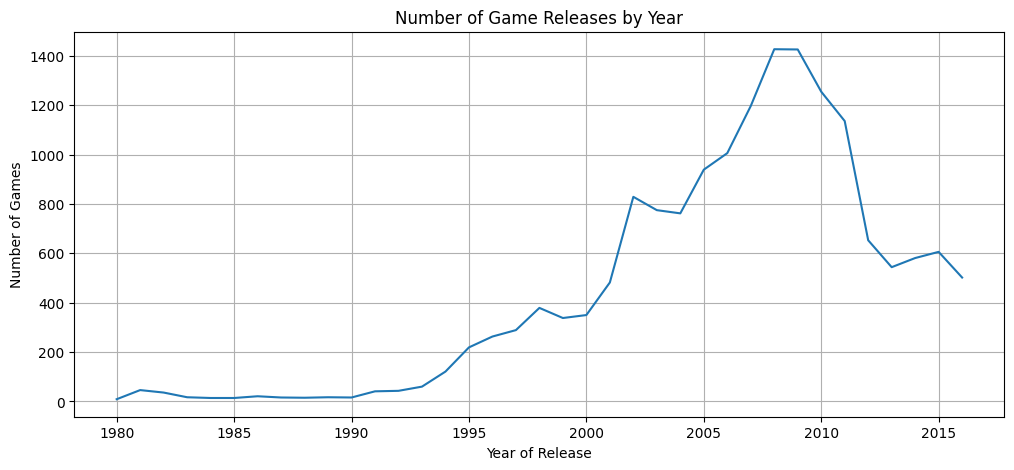

In [15]:
# Visualized the number of game releases per year as a line chart
# to visualize trends and identify periods with sparse data

games_per_year.plot(
    figsize=(12, 5),
    title='Number of Game Releases by Year',
    xlabel='Year of Release',
    ylabel='Number of Games',
    grid=True
);

plt.show()

In [16]:
# Calculated summary statistics of game releases per year

# This helps assess variability and identify typical release volumes

print(games_per_year.describe().sort_values(ascending=False))

max      1427.000000
75%       762.000000
std       451.604334
mean      444.432432
50%       338.000000
count      37.000000
25%        36.000000
min         9.000000
dtype: float64


### Summary Statistics of Game Releases

- Years after 2000 show consistently high release volumes; earlier years are sparse and less reliable.
- Releases increase steadily, peak around 2008–2009, then decline afterward.
- The 2000–2016 period provides sufficient and consistent data for forecasting.

## 3.2 Platform Sales Analysis Over Time

Next, I analyzed how sales vary across platforms and years.

In [17]:
# Calculated total sales by platform and year
# This aggregates global sales to analyze how each platform performs over time

sales_by_platform_year = (
    df.groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
)

print(sales_by_platform_year.sort_values(ascending=False).reset_index().head(10))

  platform  year_of_release  total_sales
0      PS2             2004       211.81
1      Wii             2009       206.97
2      PS2             2002       205.38
3      PS2             2003       184.31
4      Wii             2008       171.32
5     X360             2010       170.03
6       PS             1998       169.49
7      PS2             2001       166.43
8      PS2             2005       160.66
9      PS3             2011       156.78


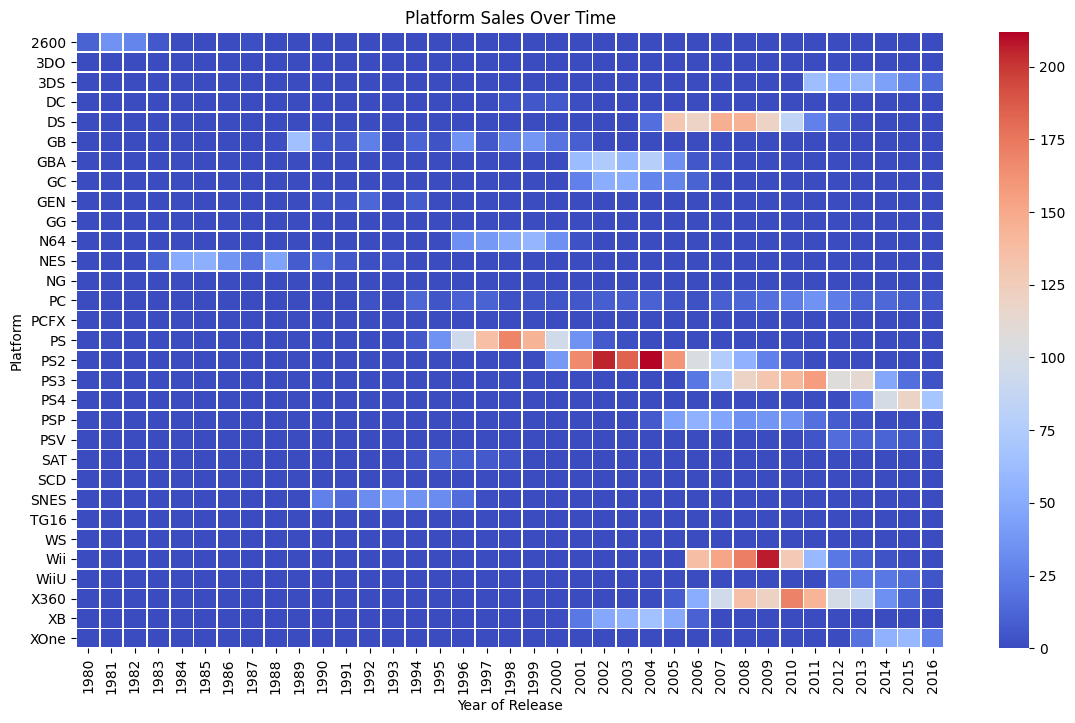

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Created a platform-by-year sales table for the heatmap
# Rows represent platforms, columns represent years, and values represent total sales

platform_sales_heatmap = df.pivot_table(
    index='platform',
    columns='year_of_release',
    values='total_sales',
    aggfunc='sum',
    fill_value=0
)

# Created a heatmap of platform sales over time
# This visual highlights which platforms were dominant in specific years

plt.figure(figsize=(14, 8))

sns.heatmap(
    platform_sales_heatmap,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Platform Sales Over Time')
plt.xlabel('Year of Release')
plt.ylabel('Platform')

plt.show()

In [19]:
# Calculated total sales per platform over time
# This allows us to observe trends and identify declining platforms

platform_sales_trend = (
    df.groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
    .unstack(fill_value=0)
)

# Identified platforms with declining sales
# Compared recent years to earlier peak performance

recent_years = platform_sales_trend.loc[:, 2013:2016].mean(axis=1)
peak_years = platform_sales_trend.max(axis=1)

declining_platforms = peak_years[recent_years < peak_years * 0.5].index

print(declining_platforms)

Index(['2600', '3DO', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES',
       'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PSP', 'SAT', 'SCD', 'SNES',
       'TG16', 'WS', 'Wii', 'X360', 'XB'],
      dtype='object', name='platform')


In [20]:
# Check which platforms had sales in the past but reached zero sales in the most recent year

platform_year_sales = (
    df
    .pivot_table(
        index='platform',
        columns='year_of_release',
        values='total_sales',
        aggfunc='sum',
        fill_value=0
    )
)

latest_year = platform_year_sales.columns.max()

platforms_zero_latest_year = platform_year_sales[
    (platform_year_sales[latest_year] == 0) &
    (platform_year_sales.drop(columns=latest_year).sum(axis=1) > 0)
]

platforms_zero_latest_year

year_of_release,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,
2600,11.38,35.68,28.88,5.84,0.27,0.45,0.67,1.94,0.74,0.63,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
3DO,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
DC,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
DS,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,...,146.94,145.31,119.54,85.02,26.18,11.01,1.54,0.00,0.00,0.0
GB,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.43,64.97,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
GBA,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
GC,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
GEN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
GG,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0


### Platforms With Zero Sales in the Most Recent Year

Several older platforms showed sales in earlier years but had zero sales in the latest year of the dataset. Examples include PS2, DS, PSP, XB, GBA, and GameCube.

This confirms that gaming platforms follow a lifecycle pattern: platforms rise in popularity, peak, decline, and are eventually replaced by newer hardware generations.

Because of this, older platform data is less useful for forecasting 2017 sales, while recent platform trends provide more relevant market insight.

### Platforms with Declining Sales

Many platforms show declining sales when recent performance from 2013–2016 is compared with their historical peak sales.

This includes older platforms such as `PS2`, `DS`, `Wii`, `PS`, `NES`, `SNES`, and `XB`, which appear to have completed their sales lifecycles.

Some more recent platforms, including `PS3`, `X360`, `3DS`, `PC`, and `PSP`, also show lower recent sales compared with their earlier peaks.

Overall, the results suggest that platform lifecycles are limited: platforms rise, peak, and then decline as newer systems replace them.

### Platform Trends and Lifecycle

Platforms such as `PS3`, `X360`, `PS4`, and `XOne` show more consistent sales over time, with sustained activity across multiple years.

Several platforms have effectively disappeared from the market, including `PS2`, `DS`, `Wii`, `NES`, `SNES`, and `XB`, as their sales drop to near zero in later years.

Overall, gaming platforms follow a clear lifecycle: introduction, growth, peak sales, and eventual decline. Based on the data, this lifecycle typically spans around 5–10 years before being replaced by newer platforms.

## 3.3 Determining Relevant Time Period

Determined the appropriate time period for predicting 2017 sales based on analysis above:

In [21]:
# Filtered dataset to recent years for forecasting relevance
# Focused on 2012–2016 to capture current platform trends leading into 2017

df_relevant = df[df['year_of_release'] >= 2012]

df_relevant['year_of_release'].value_counts().sort_index()

2012    653
2013    544
2014    581
2015    606
2016    502
Name: year_of_release, dtype: Int64

### Relevant Time Period Selection

Years selected: 2012–2016.

This period reflects current market conditions by focusing on active platforms such as PS4 and XOne, while excluding older platforms that are no longer relevant.

The decision was based on observed platform lifecycles, declining sales of older systems, and the need to use recent data for accurate 2017 forecasting.

Older platform data was excluded because gaming platforms have relatively short lifecycles. Otherwise, outdated platforms could distort forecasts for 2017.

## 3.4 Platform Performance Analysis

Analyzed platform performance using the selected relevant period of 2012–2016.

In [22]:
# Calculated platform performance for the relevant forecasting period

platform_performance = (
    df_relevant
    .groupby('platform')
    .agg(
        total_sales=('total_sales', 'sum'),
        average_sales=('total_sales', 'mean'),
        median_sales=('total_sales', 'median'),
        games_released=('name', 'count')
    )
    .sort_values('total_sales', ascending=False)
)

In [23]:
# Identified leading platforms by total global sales

top_platforms = platform_performance.head(10)

print(top_platforms)

          total_sales  average_sales  median_sales  games_released
platform                                                          
PS4            314.14       0.801378          0.20             392
PS3            288.79       0.585781          0.20             493
X360           236.54       0.810068          0.31             292
3DS            194.61       0.491439          0.11             396
XOne           159.32       0.645020          0.22             247
WiiU            82.19       0.559116          0.22             147
PC              62.65       0.250600          0.08             250
PSV             49.18       0.119659          0.05             411
Wii             35.37       0.655000          0.18              54
DS              12.55       0.404839          0.05              31


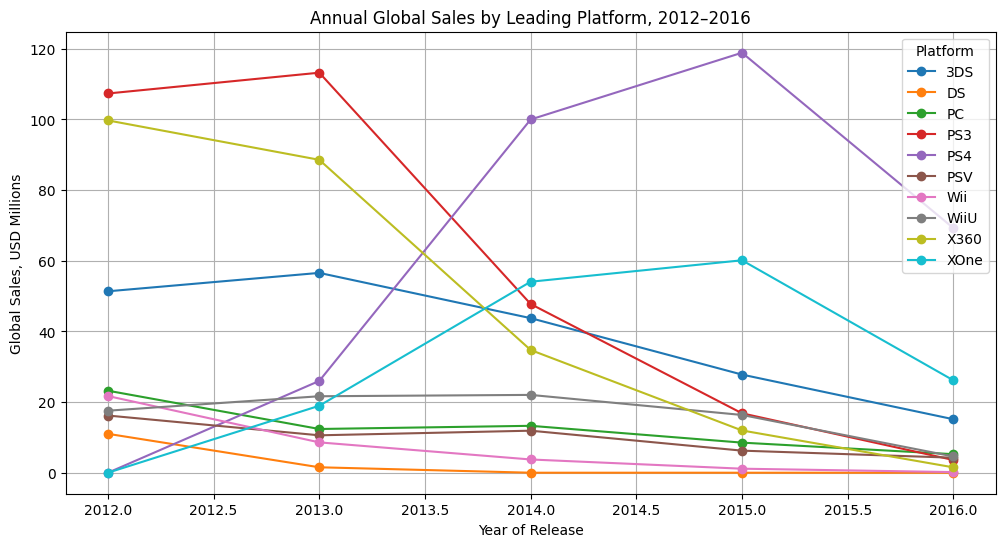

In [24]:
# Visualized annual sales trends for the leading platforms

top_platform_names = top_platforms.index

platform_sales_by_year = (
    df_relevant[df_relevant['platform'].isin(top_platform_names)]
    .pivot_table(
        index='year_of_release',
        columns='platform',
        values='total_sales',
        aggfunc='sum',
        fill_value=0
    )
)

platform_sales_by_year.plot(figsize=(12, 6), marker='o')

plt.title('Annual Global Sales by Leading Platform, 2012–2016')
plt.xlabel('Year of Release')
plt.ylabel('Global Sales, USD Millions')
plt.grid(True)
plt.legend(title='Platform')
plt.show()

### Analysis of Annual Platform Sales Trends

- **Generational replacement pattern:** New console releases consistently replace prior ones (PS3 → PS4, X360 → XOne), driving sharp declines in older platforms.
- **Sony vs Microsoft:** Both follow the same cycle, but PS4 outperforms XOne, widening the gap in market leadership during this period.
- **Nintendo position:** Wii and WiiU trail significantly behind both Sony and Microsoft, indicating weaker competitive positioning in this dataset.
- **Market structure:** The industry is dominated by Sony and Microsoft, with Nintendo operating on a separate, smaller trajectory.
- **PS4:** Clear market leader; strongest sales and peak performance in 2015.
- **XOne:** Solid second-place platform; follows similar lifecycle but at lower scale.
- **3DS and PC:** While both remain relevant, both are in decline.
- **Forward pattern:** Based on observed cycles, a new PlayStation and Xbox generation is the most likely next shift, which would eventually reduce PS4 and XOne sales.

- **Conclusion:** PS4 and XOne are the most relevant platforms for 2017, but both are mid-cycle and will eventually be displaced by next-generation releases.

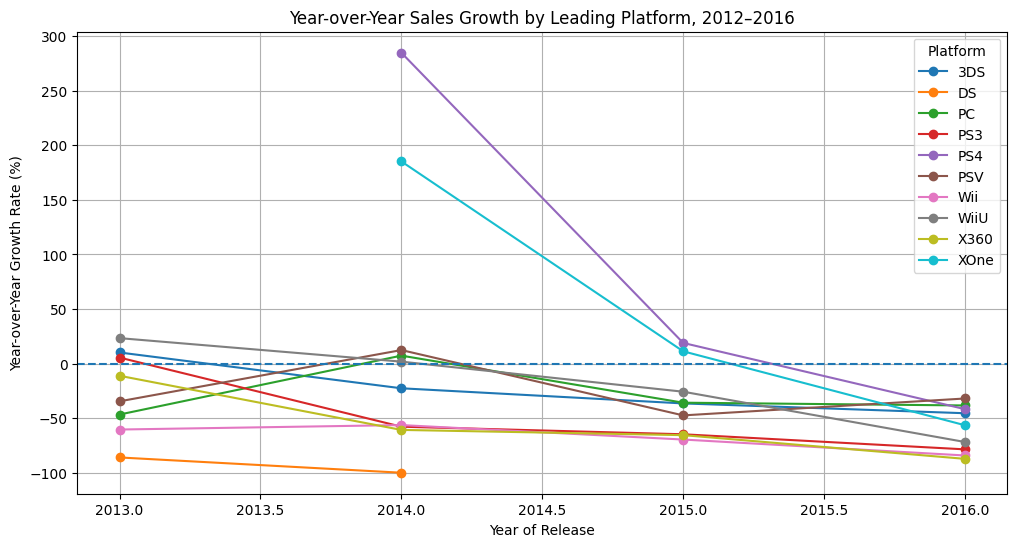

In [25]:
# Calculated year-over-year sales growth for each leading platform

platform_growth_rates = platform_sales_by_year.pct_change() * 100

platform_growth_rates


# Visualized year-over-year sales growth rates for the leading platforms

platform_growth_rates.plot(figsize=(12, 6), marker='o')

plt.title('Year-over-Year Sales Growth by Leading Platform, 2012–2016')
plt.xlabel('Year of Release')
plt.ylabel('Year-over-Year Growth Rate (%)')
plt.axhline(0, linestyle='--')
plt.grid(True)
plt.legend(title='Platform')
plt.show()

### Platform Lifecycle Trends

- PS4 and XOne experienced strong early growth after release.
- Older platforms like PS3 and X360 declined as newer consoles entered the market.
- Most platforms follow a similar cycle of growth, peak popularity, and decline.
- VR showed strong growth in 2016, though from a relatively small sales base.
- PC sales remained more stable because the platform does not rely on a fixed hardware cycle.
- Some 2016 declines may reflect incomplete yearly data.

**Conclusion:**  
PS4 and XOne appear to be the strongest platforms for 2017, while VR may represent an emerging growth area worth monitoring.

## 3.5 Sales Distribution Analysis

Analyzed the distribution of global game sales across platforms to assess variability, outliers, and differences in typical performance.

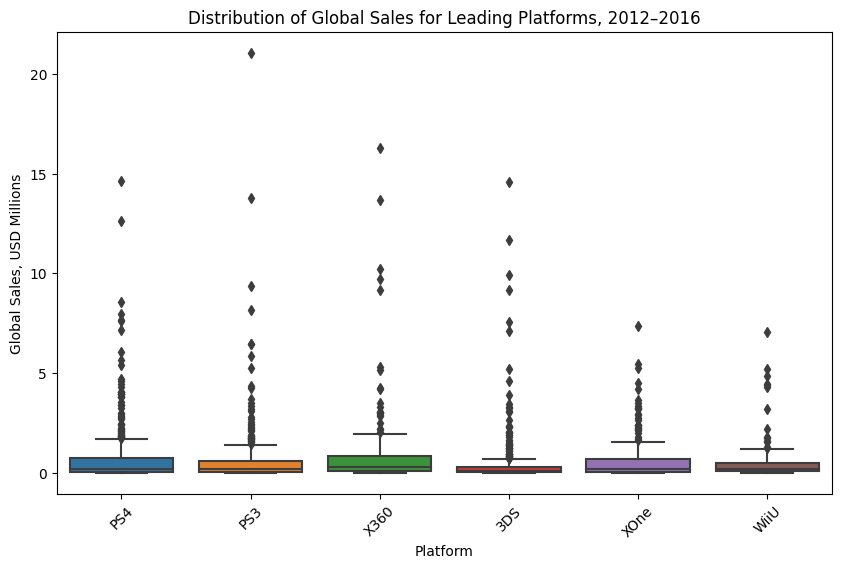

In [53]:
# Built box plot to compare global sales distributions for leading platforms

leading_platforms = (
    df_relevant
    .groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

df_leading_platforms = df_relevant[df_relevant['platform'].isin(leading_platforms)]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_leading_platforms,
    x='platform',
    y='total_sales',
    order=leading_platforms
)

plt.title('Distribution of Global Sales for Leading Platforms, 2012–2016')
plt.xlabel('Platform')
plt.ylabel('Global Sales, USD Millions')
plt.xticks(rotation=45)
plt.show()

### Analysis of Sales Distribution by Platform

- Most games across all platforms show relatively low sales, while a small number of titles achieve very large sales figures.
- PS4, PS3, and X360 contain the largest outliers, indicating several blockbuster-level games.
- The middle 50% of sales remain fairly compressed across platforms, showing that typical games sell modestly.
- PS4, PS3, X360, and 3DS display wider distributions and greater variability than smaller platforms.
- WiiU and XOne show fewer extreme outliers compared to PS3 and X360.

**Conclusion:**  
Sales performance across platforms is highly uneven, with a small number of successful titles generating a large share of total revenue.

In [27]:
# Calculated detailed summary statistics for each platform

platform_stats = (
    df_relevant
    .groupby('platform')['total_sales']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max'
    ])
    .sort_values('mean', ascending=False)
)

platform_stats

,count,mean,median,std,min,max
platform,,,,,,
X360,292,0.810068,0.31,1.712069,0.01,16.27
PS4,392,0.801378,0.20,1.609456,0.01,14.63
Wii,54,0.655000,0.18,1.165447,0.01,6.76
XOne,247,0.645020,0.22,1.036139,0.01,7.39
PS3,493,0.585781,0.20,1.462855,0.01,21.05
WiiU,147,0.559116,0.22,1.058836,0.01,7.09
3DS,396,0.491439,0.11,1.387161,0.01,14.60
DS,31,0.404839,0.05,1.439245,0.01,8.06
PC,250,0.250600,0.08,0.494640,0.01,5.14


### Platform Sales Statistics

- X360 and PS4 have the highest average sales per game.
- PS3 released the largest number of titles, but average sales were lower.
- Median sales remain low across all platforms, showing that most games sold modestly.
- Large standard deviations and maximum values on platforms like PS3, X360, and PS4 indicate that a small number of blockbuster titles heavily influenced sales totals.
- PC and handheld platforms generally showed lower sales performance overall.

**Conclusion:**  
Game sales are highly uneven across all platforms, with a few major hits driving most overall revenue.

## 3.6 Review Score Impact Analysis

Analyzed how critic and user review scores relate to global sales for PS4, the leading current-generation platform in the selected period.

In [28]:
# Selected PS4, considering it's the leading platform, in terms of sales, within the relevant period

selected_platform = 'PS4'

platform_reviews = df_relevant[
    (df_relevant['platform'] == selected_platform) &
    (df_relevant['critic_score'].notna()) &
    (df_relevant['user_score'].notna())
]

platform_reviews[['name', 'platform', 'critic_score', 'user_score', 'total_sales']].head()

,name,platform,critic_score,user_score,total_sales
42,Grand Theft Auto V,PS4,97,8.3,12.62
77,FIFA 16,PS4,82,4.3,8.58
92,Call of Duty: Advanced Warfare,PS4,83,5.7,7.66
94,FIFA 17,PS4,85,5.0,7.60
105,Fallout 4,PS4,87,6.5,7.17


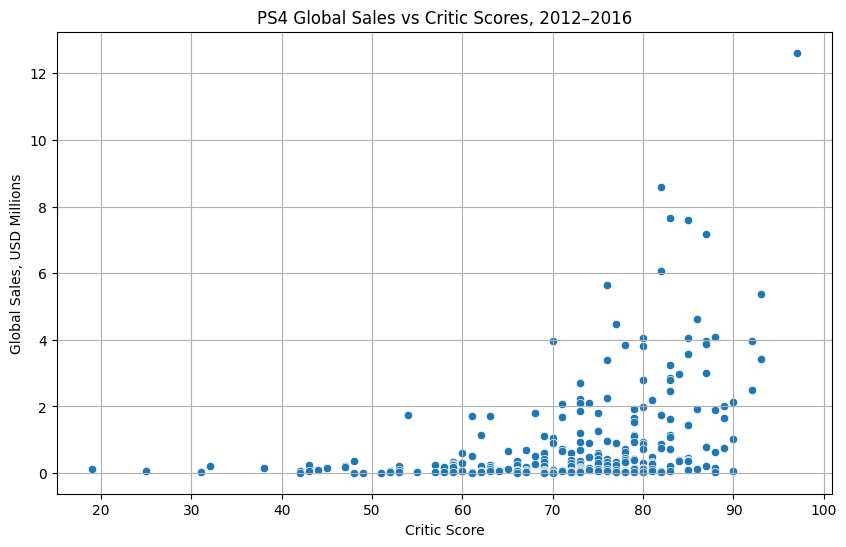

In [29]:
# Visualized relationship between critic scores and global sales for PS4

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=platform_reviews,
    x='critic_score',
    y='total_sales'
)

plt.title('PS4 Global Sales vs Critic Scores, 2012–2016')
plt.xlabel('Critic Score')
plt.ylabel('Global Sales, USD Millions')
plt.grid(True)
plt.show()

### Analysis of Critic Scores and PS4 Sales

- **Positive relationship:** Higher critic scores generally align with higher sales.
- **High variance:** Strong reviews do not guarantee high sales.
- **Outliers:** A few highly rated games generate much larger sales than the rest.
- **Low-score limitation:** Lower-rated games rarely become major sales successes.
- **Conclusion:** Critic scores appear useful as one success indicator, but they are not sufficient on their own.

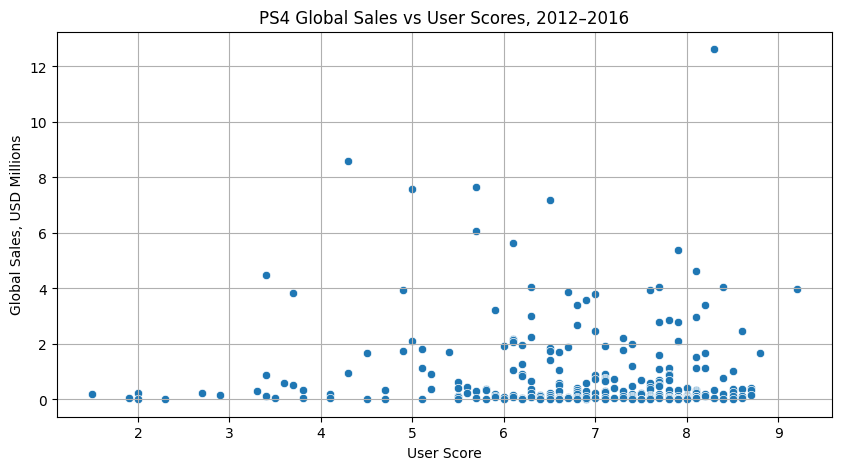

In [30]:
# Created scatter plot to compare user scores with global sales for PS4

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=platform_reviews,
    x='user_score',
    y='total_sales'
)

plt.title('PS4 Global Sales vs User Scores, 2012–2016')
plt.xlabel('User Score')
plt.ylabel('Global Sales, USD Millions')
plt.grid(True)
plt.show()

### Analysis of User Scores and PS4 Sales

- **Weaker relationship:** User scores show less visible connection with sales than critic scores.
- **Wide spread:** Games with similar user scores can have very different sales outcomes.
- **Outliers:** High-selling games appear across a range of user scores. This suggests that user scores are less consistent indicators of sales performance than critic scores.
- **Interpretation:** User ratings are less useful than critic scores for identifying potential high-sales titles.

In [31]:
# Calculated correlations between review scores and global sales for PS4

review_correlations = platform_reviews[
    ['critic_score', 'user_score', 'total_sales']
].corr()

review_correlations['total_sales'].sort_values(ascending=False)

total_sales     1.000000
critic_score    0.405895
user_score     -0.033625
Name: total_sales, dtype: float64

### Review Scores and Sales

The correlation results show that critic scores have a moderate positive relationship with PS4 total sales. This matches the scatterplot: games with higher critic scores generally tend to have stronger sales, although there are still exceptions.

User scores have a much weaker relationship with sales. The user-score scatterplot is more spread out, which suggests that player ratings are less reliable for estimating sales potential.

Overall, critic reviews provide more useful sales signal than user reviews, but review scores alone do not fully explain game performance.

## 3.7 Cross-Platform Comparison

Compared sales of the same games across platforms to evaluate whether PS4 sales patterns are consistent with performance on other systems.

In [54]:
# Identified PS4 games that also appeared on other platforms

ps4_game_names = platform_reviews['name'].unique()

cross_platform_data = df_relevant[
    df_relevant['name'].isin(ps4_game_names)
]

cross_platform_sales = (
    cross_platform_data
    .pivot_table(
        index='name',
        columns='platform',
        values='total_sales',
        aggfunc='sum'
    )
)

cross_platform_sales.head()

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
7 Days to Die,NaN,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,0.05
Aegis of Earth: Protonovus Assault,NaN,NaN,NaN,0.02,0.02,NaN,0.03,NaN,NaN,NaN,NaN
Agatha Christie's The ABC Murders,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,0.01
Alien: Isolation,NaN,NaN,0.15,0.33,1.12,NaN,NaN,NaN,NaN,0.27,0.50
Angry Birds Star Wars,0.33,NaN,NaN,0.29,0.22,NaN,0.08,0.26,0.1,0.28,0.17


In [33]:

# Compared average sales of shared games across platforms

shared_game_platform_summary = (
    cross_platform_data
    .groupby('platform')
    .agg(
        shared_games=('name', 'count'),
        average_sales=('total_sales', 'mean'),
        median_sales=('total_sales', 'median'),
        total_sales=('total_sales', 'sum')
    )
    .sort_values('average_sales', ascending=False)
)

shared_game_platform_summary


,shared_games,average_sales,median_sales,total_sales
platform,,,,
Wii,9,1.221111,0.950,10.99
X360,73,1.162740,0.430,84.88
PS3,100,0.981600,0.365,98.16
PS4,249,0.981004,0.300,244.27
XOne,157,0.655605,0.270,102.93
DS,1,0.380000,0.380,0.38
WiiU,26,0.355385,0.320,9.24
3DS,17,0.314118,0.240,5.34
PC,83,0.210723,0.090,17.49


### Analysis of Shared Game Sales by Platform

This comparison isolates games that appeared on PS4 and at least one other platform. PS4 has the largest number of shared titles in this group, with 249 games and total sales of 244.27 million. This shows that PS4 had the strongest overall sales base among the shared titles.

However, the average sales comparison is more mixed. Among major platforms, X360 has the highest average sales per shared title at 1.16 million, while PS3 and PS4 are nearly equal at about 0.98 million. XOne is lower, with average sales of about 0.66 million per shared title.

This means that shared games did not always sell best on PS4. Some older platforms, especially X360 and PS3, still had strong sales for certain shared games. At the same time, PS4 had the largest total sales because it had many more shared titles.

Overall, the comparison shows that platform lifecycle and audience size matter. PS4 was the strongest platform overall for shared titles, but X360 and PS3 remained important exceptions for some games.

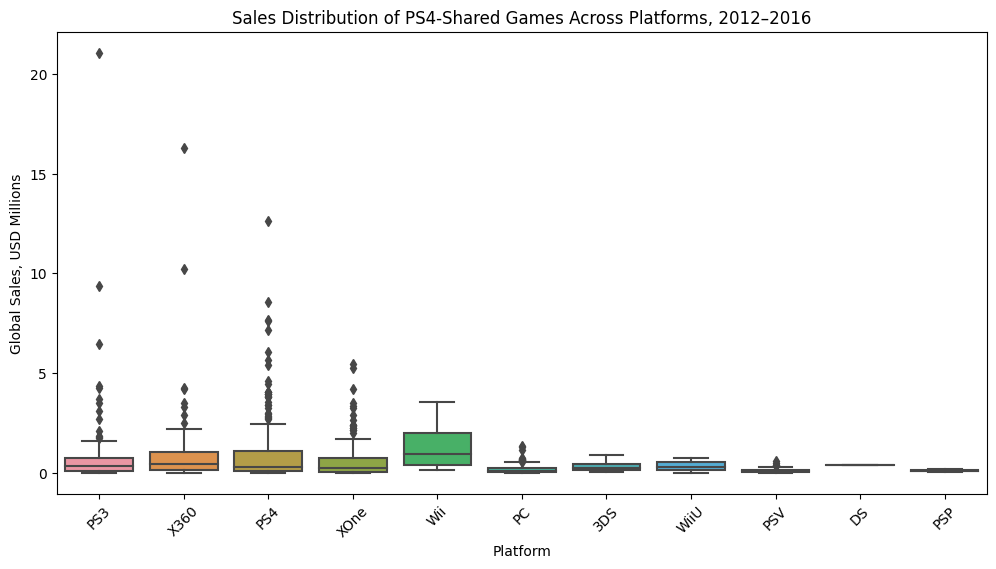

In [34]:
# Visualized sales of shared games across platforms

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=cross_platform_data,
    x='platform',
    y='total_sales'
)

plt.title('Sales Distribution of PS4-Shared Games Across Platforms, 2012–2016')
plt.xlabel('Platform')
plt.ylabel('Global Sales, USD Millions')
plt.xticks(rotation=45)
plt.show()

### Shared Game Sales Across Platforms

- **Right-skewed sales:** Shared games still show hit-driven sales across platforms.
- **Major consoles:** PS4, XOne, PS3, and X360 show the strongest upside for shared titles.
- **Platform lifecycle:** Newer platforms benefit from current market attention, while older platforms decline despite familiar titles.
- **Nintendo and handhelds:** Shared-title performance is weaker or less comparable due to different audiences and game catalogs.
- **Conclusion:** Cross-platform results support PS4 and XOne as the most relevant 2017 platforms, while reinforcing that platform context affects sales outcomes.

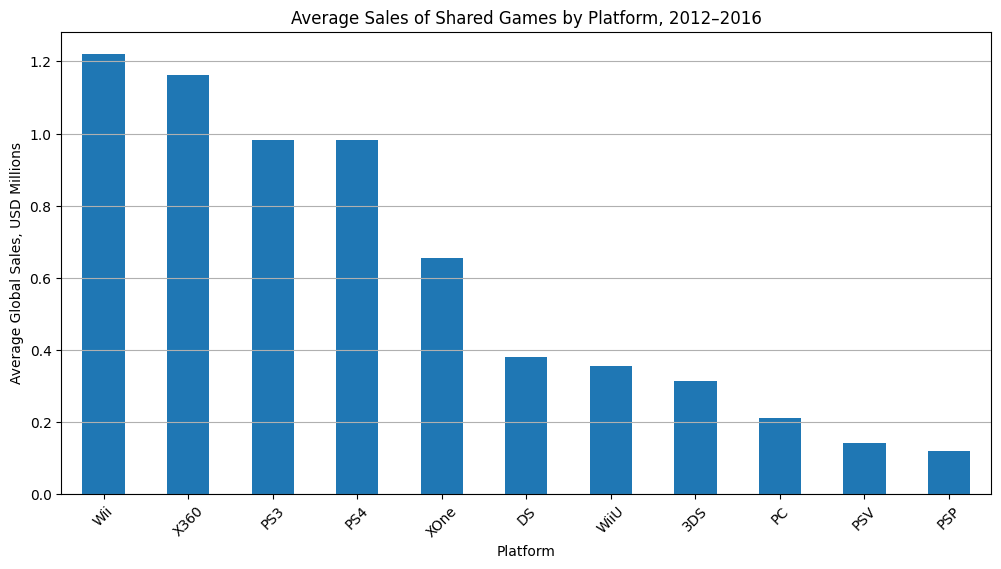

In [35]:
# Visualized average sales of shared games by platform

avg_sales_shared = (
    cross_platform_data
    .groupby('platform')['total_sales']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

avg_sales_shared.plot(kind='bar')

plt.title('Average Sales of Shared Games by Platform, 2012–2016')
plt.xlabel('Platform')
plt.ylabel('Average Global Sales, USD Millions')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

### Average Sales Comparison Across Platforms

- **Weak cross-platform consistency:** Overall platform strength does not fully predict shared-game performance.
- **PS4 context:** PS4 leads in total platform sales, but it is not the top performer for cross-platform average sales.
- **Top shared-game averages:** Wii and X360 lead this subset, likely due to a smaller group of high-performing shared titles.
- **Current-generation comparison:** PS4 performs close to PS3, while XOne trails PS4.
- **Conclusion:** Cross-platform sales vary by platform, but the relationship is not simple. A strong overall platform does not guarantee the highest average sales for shared titles.

## 3.8 Genre Analysis

Analyzed genre performance to identify which categories generate the strongest total sales, highest average sales, and most reliable market potential.

In [36]:
# Calculated genre-level sales statistics

genre_stats = (
    df_relevant
    .groupby('genre')
    .agg(
        games_released=('name', 'count'),
        total_sales=('total_sales', 'sum'),
        average_sales=('total_sales', 'mean'),
        median_sales=('total_sales', 'median'),
        std_sales=('total_sales', 'std')
    )
    .sort_values('total_sales', ascending=False)
)

genre_stats

,games_released,total_sales,average_sales,median_sales,std_sales
genre,,,,,
Action,1031,441.12,0.427856,0.120,1.166504
Shooter,235,304.73,1.296723,0.440,2.251662
Role-Playing,370,192.80,0.521081,0.140,1.315937
Sports,268,181.07,0.675634,0.240,1.136378
Misc,192,85.04,0.442917,0.120,1.081047
Platform,85,61.00,0.717647,0.210,1.364413
Racing,115,53.50,0.465217,0.140,0.888664
Fighting,109,44.49,0.408165,0.130,0.910385
Simulation,80,35.12,0.439000,0.120,1.244500


In [1]:
# Visualized total global sales by genre

genre_stats['total_sales'].plot(kind='bar', figsize=(12, 6))

plt.title('Total Global Sales by Genre, 2012–2016')
plt.xlabel('Genre')
plt.ylabel('Total Global Sales, USD Millions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

NameError: name 'genre_stats' is not defined

### Analysis of Total Sales by Genre

- **Action:** Highest total sales, driven partly by the largest number of releases.
- **Shooter:** Second-highest total sales despite fewer releases.
- **Role-Playing and Sports:** Strong total sales and clear commercial relevance.
- **Adventure:** Many releases, but weak total sales.
- **Puzzle and Strategy:** Lowest total sales in this period.
- **Conclusion:** Total sales favor broad, high-volume genres, especially Action, Shooter, Role-Playing, and Sports.

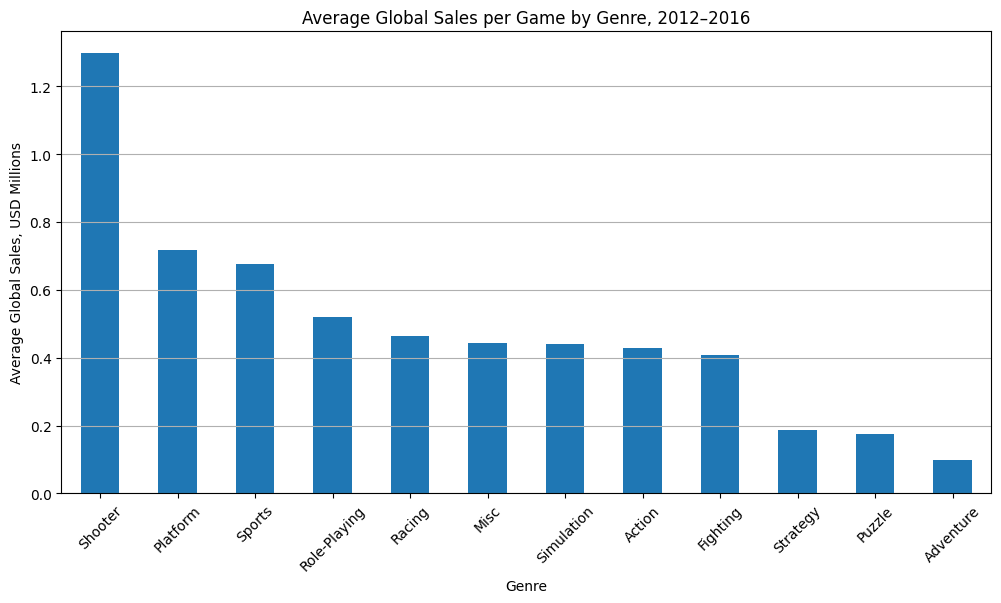

In [ ]:
# Visualized average global sales by genre

genre_stats.sort_values('average_sales', ascending=False)['average_sales'].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Global Sales per Game by Genre, 2012–2016')
plt.xlabel('Genre')
plt.ylabel('Average Global Sales, USD Millions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Analysis of Average Sales by Genre

- **Shooter:** Highest average sales per game; strongest genre by per-title performance.
- **Platform, Sports, and Role-Playing:** Strong average sales with meaningful upside.
- **Action:** Leads total sales, but average sales are lower because the genre has many releases.
- **Adventure:** Low average and median sales despite high release volume.
- **Conclusion:** Shooter is the strongest genre for individual title performance, while Action is strongest by total market size.

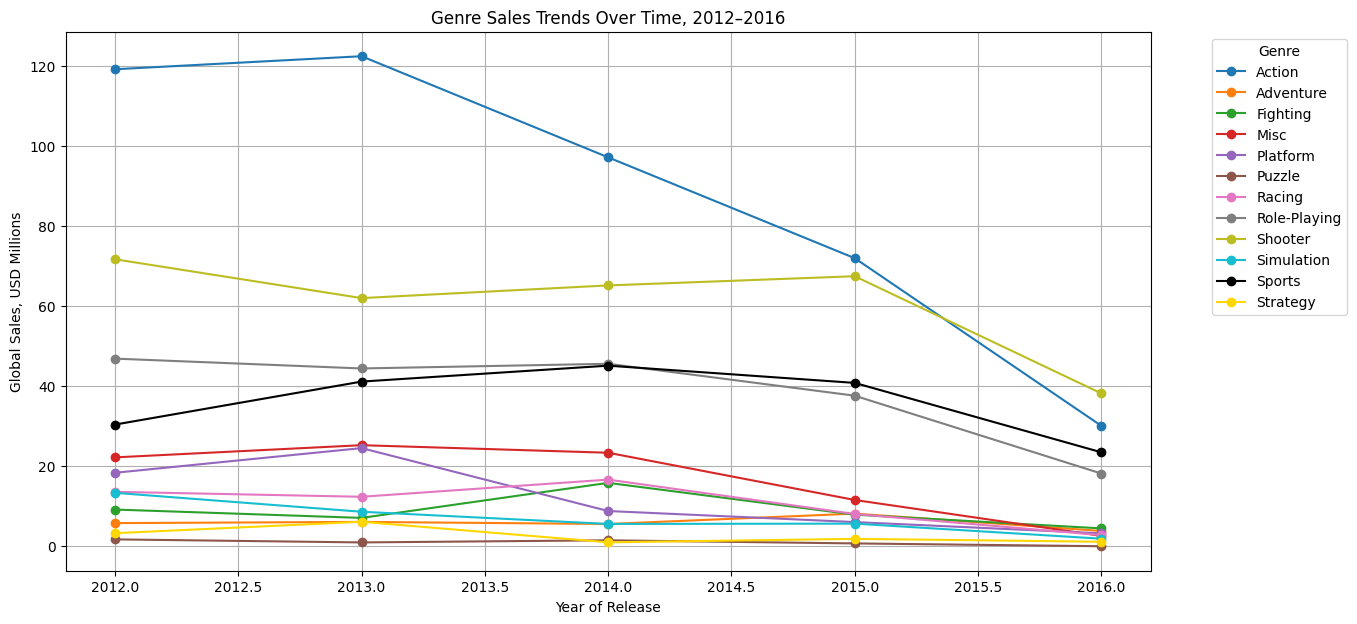

In [ ]:
# Analyzed genre sales trends over time

genre_sales_by_year = (
    df_relevant
    .pivot_table(
        index='year_of_release',
        columns='genre',
        values='total_sales',
        aggfunc='sum',
        fill_value=0
    )
)

plt.figure(figsize=(14, 7))

line_styles = {
    'Action': ('tab:blue', '-'),
    'Adventure': ('tab:orange', '-'),
    'Fighting': ('tab:green', '-'),
    'Misc': ('tab:red', '-'),
    'Platform': ('tab:purple', '-'),
    'Puzzle': ('tab:brown', '-'),
    'Racing': ('tab:pink', '-'),
    'Role-Playing': ('tab:gray', '-'),
    'Shooter': ('tab:olive', '-'),
    'Simulation': ('tab:cyan', '-'),
    'Sports': ('black', '-'),
    'Strategy': ('gold', '-')
}

for genre in genre_sales_by_year.columns:
    color, style = line_styles.get(genre, ('black', '-'))
    
    plt.plot(
        genre_sales_by_year.index,
        genre_sales_by_year[genre],
        label=genre,
        color=color,
        linestyle=style,
        marker='o'
    )

plt.title('Genre Sales Trends Over Time, 2012–2016')
plt.xlabel('Year of Release')
plt.ylabel('Global Sales, USD Millions')

plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)

plt.show()

### Analysis of Genre Sales Trends

- **Shooter:** Strong growth through the middle of the period; remains one of the top-performing genres.
- **Action:** Maintains the largest overall market presence, though growth stabilizes later in the period.
- **Role-Playing:** Shows relatively stable performance with gradual growth.
- **Sports:** Remains commercially strong with moderate fluctuation.
- **Adventure and Puzzle:** Consistently weak sales throughout the period.
- **Industry pattern:** High-action and multiplayer-oriented genres dominate market growth during this console generation.
- **Conclusion:** Shooter, Action, Sports, and Role-Playing show the strongest long-term commercial potential, while Adventure and Puzzle continue to underperform.

In [ ]:
# Calculated market share for each genre

genre_market_share = (
    genre_stats['total_sales'] / genre_stats['total_sales'].sum() * 100
).round(2)

genre_market_share

genre
Action          30.50
Shooter         21.07
Role-Playing    13.33
Sports          12.52
Misc             5.88
Platform         4.22
Racing           3.70
Fighting         3.08
Simulation       2.43
Adventure        2.03
Strategy         0.92
Puzzle           0.34
Name: total_sales, dtype: float64

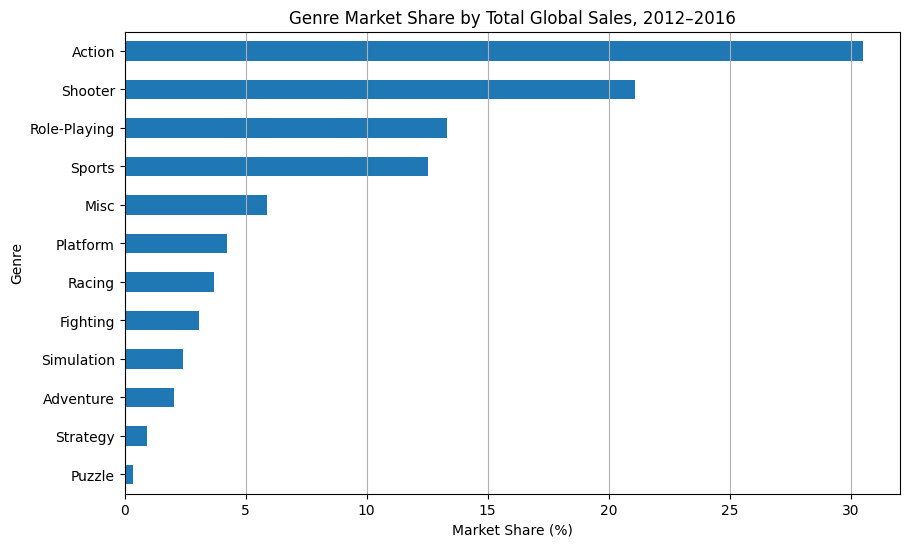

In [ ]:
# Visualized genre market share percentages

genre_market_share.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Genre Market Share by Total Global Sales, 2012–2016')
plt.xlabel('Market Share (%)')
plt.ylabel('Genre')
plt.grid(axis='x')

plt.show()

### Genre Market Share Findings

- **Highest market share:** Action, Shooter, Role-Playing, and Sports dominate global sales.
- **Best balance:** Shooter combines high total sales with the strongest average sales.
- **High-risk volume genre:** Action is commercially important but crowded.
- **Lower-potential genres:** Puzzle, Strategy, and Adventure show weaker sales potential.
- **Conclusion:** For 2017 planning, Shooter, Action, Sports, and Role-Playing are the strongest genre candidates, with Shooter offering the best per-title upside.

# Step 4: Regional Market Analysis and User Profiles

Created regional user profiles for North America, Europe, and Japan by comparing platform preferences, genre preferences, and ESRB rating impact.

## 4.1 Regional Platform Analysis

Compared the top platforms in North America, Europe, and Japan to identify regional differences in market share.

In [ ]:
# Calculated top five platforms by region

regions = {
    'North America': 'na_sales',
    'Europe': 'eu_sales',
    'Japan': 'jp_sales'
}

for region_name, sales_column in regions.items():
    platform_share = (
        df_relevant
        .groupby('platform')[sales_column]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    
    platform_share_percent = (platform_share / df_relevant[sales_column].sum() * 100).round(2)
    
    print(f'\nTop 5 Platforms in {region_name}')
    display(
        pd.DataFrame({
            'sales': platform_share,
            'market_share_percent': platform_share_percent
        })
    )


Top 5 Platforms in North America


,sales,market_share_percent
platform,,
X360,140.05,23.70
PS4,108.74,18.40
PS3,103.38,17.49
XOne,93.12,15.76
3DS,55.31,9.36



Top 5 Platforms in Europe


,sales,market_share_percent
platform,,
PS4,141.09,27.84
PS3,106.86,21.08
X360,74.52,14.70
XOne,51.59,10.18
3DS,42.64,8.41



Top 5 Platforms in Japan


,sales,market_share_percent
platform,,
3DS,87.79,45.59
PS3,35.29,18.32
PSV,21.04,10.93
PS4,15.96,8.29
WiiU,13.01,6.76


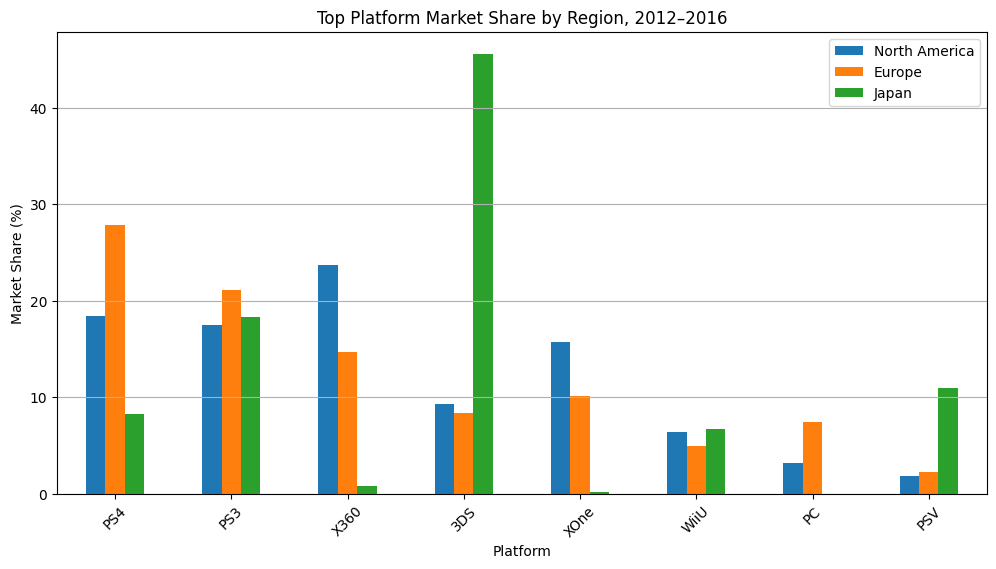

In [ ]:
# Visualized top platform market shares by region

regional_platform_sales = pd.DataFrame()

for region_name, sales_column in regions.items():
    regional_platform_sales[region_name] = (
        df_relevant
        .groupby('platform')[sales_column]
        .sum()
    )

top_regional_platforms = regional_platform_sales.sum(axis=1).sort_values(ascending=False).head(8).index

regional_platform_share = (
    regional_platform_sales.loc[top_regional_platforms]
    / regional_platform_sales.sum()
    * 100
).round(2)

regional_platform_share.plot(kind='bar', figsize=(12, 6))

plt.title('Top Platform Market Share by Region, 2012–2016')
plt.xlabel('Platform')
plt.ylabel('Market Share (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Regional Platform Findings

- **North America:** Microsoft Xbox platforms (X360, XOne) and Sony PlayStation platforms (PS3, PS4) are both highly competitive.
- **Europe:** Sony PlayStation platforms (PS3, PS4) hold stronger market share than Microsoft Xbox platforms (X360, XOne).
- **Japan:** Nintendo platforms (3DS, WiiU) and Sony handheld platforms (PSV) are more important than in Western markets.
- **Regional difference:** Platform success varies significantly across regions.
- **Conclusion:** Marketing strategy should be region-specific rather than based only on global platform sales.

## 4.2 Regional Genre Analysis

Compared the top genres in each region to identify differences in player preferences.

In [ ]:
# Calculated top five genres by region

for region_name, sales_column in regions.items():
    genre_share = (
        df_relevant
        .groupby('genre')[sales_column]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    
    genre_share_percent = (genre_share / df_relevant[sales_column].sum() * 100).round(2)
    
    print(f'\nTop 5 Genres in {region_name}')
    display(
        pd.DataFrame({
            'sales': genre_share,
            'market_share_percent': genre_share_percent
        })
    )


Top 5 Genres in North America


,sales,market_share_percent
genre,,
Action,177.84,30.09
Shooter,144.77,24.50
Sports,81.53,13.80
Role-Playing,64.00,10.83
Misc,38.19,6.46



Top 5 Genres in Europe


,sales,market_share_percent
genre,,
Action,159.34,31.44
Shooter,113.47,22.39
Sports,69.09,13.63
Role-Playing,48.53,9.58
Racing,27.29,5.38



Top 5 Genres in Japan


,sales,market_share_percent
genre,,
Role-Playing,65.44,33.98
Action,52.80,27.42
Misc,12.86,6.68
Simulation,10.41,5.41
Fighting,9.44,4.90


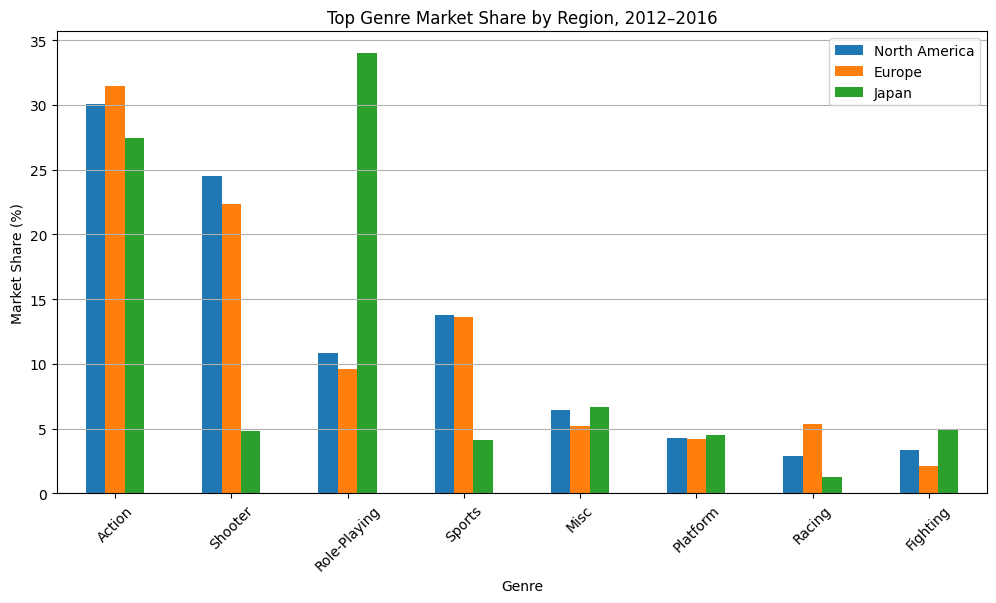

In [ ]:
# Visualized top genre market shares by region

regional_genre_sales = pd.DataFrame()

for region_name, sales_column in regions.items():
    regional_genre_sales[region_name] = (
        df_relevant
        .groupby('genre')[sales_column]
        .sum()
    )

top_regional_genres = regional_genre_sales.sum(axis=1).sort_values(ascending=False).head(8).index

regional_genre_share = (
    regional_genre_sales.loc[top_regional_genres]
    / regional_genre_sales.sum()
    * 100
).round(2)

regional_genre_share.plot(kind='bar', figsize=(12, 6))

plt.title('Top Genre Market Share by Region, 2012–2016')
plt.xlabel('Genre')
plt.ylabel('Market Share (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Regional Genre Findings

- **North America and Europe:** Action, Shooter, Sports, and Role-Playing are major revenue drivers.
- **Japan:** Role-Playing has stronger relative importance than in Western markets.
- **Shooter:** Performs especially well in Western regions.
- **Action:** Broadest global appeal across all regions.
- **Conclusion:** Genre preferences vary by region, especially between Japan and Western markets.

## 4.3 ESRB Rating Impact Analysis

Analyzed whether ESRB ratings affect regional sales patterns.

In [ ]:
# Calculated sales by ESRB rating for each region

rating_sales = (
    df_relevant
    .groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']]
    .sum()
)

rating_sales

,na_sales,eu_sales,jp_sales
rating,,,
E,114.37,113.03,28.33
E10+,75.70,55.37,8.19
M,231.57,193.96,21.20
T,66.02,52.96,26.02
Unknown,103.31,91.50,108.84


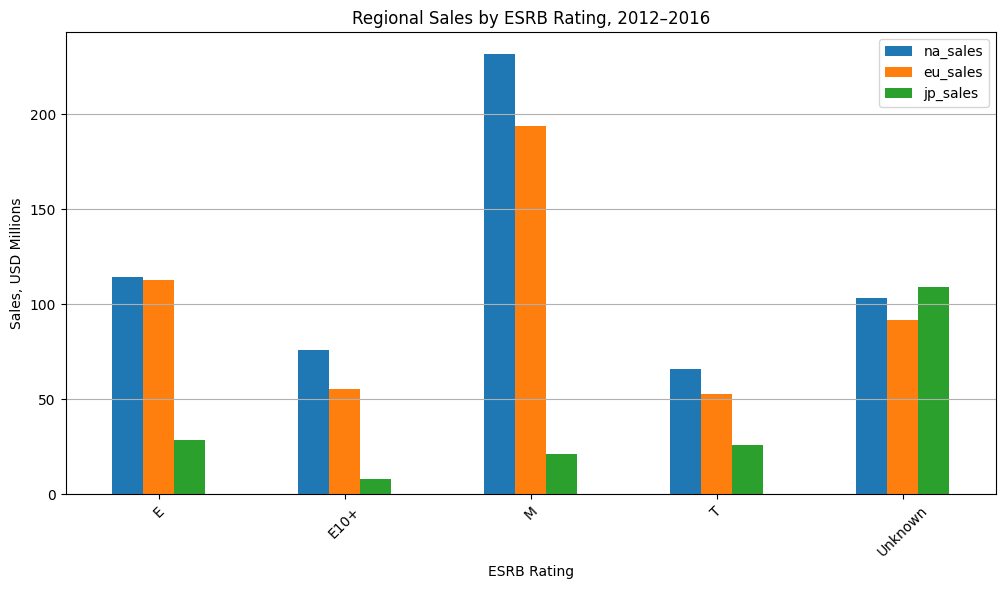

In [ ]:
# Visualized ESRB rating sales by region

rating_sales.plot(kind='bar', figsize=(12, 6))

plt.title('Regional Sales by ESRB Rating, 2012–2016')
plt.xlabel('ESRB Rating')
plt.ylabel('Sales, USD Millions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### ESRB Rating Findings

- **North America and Europe:** Mature and Everyone-rated games account for major sales.
- **Japan:** ESRB rating patterns are less dominant, partly because many Japanese-market games have missing or non-ESRB ratings.
- **Missing ratings:** Missing ESRB values likely reflect regional rating-system differences or incomplete source data.
- **Conclusion:** ESRB rating appears more useful for Western market analysis than for Japan.

# Step 5: Hypothesis Tests

The following hypothesis tests were performed to determine whether differences in average user ratings between platforms and genres were statistically significant.

## 5.1 Xbox One vs PC User Ratings

Tested whether average user ratings differ between Xbox One and PC games.

### Hypotheses

- **Null hypothesis (H₀):** Average user ratings for Xbox One and PC games are the same.
- **Alternative hypothesis (H₁):** Average user ratings for Xbox One and PC games are different.

I used a two-sample t-test because the comparison involves the means of two independent groups.

In [ ]:
# Prepared user score samples for Xbox One and PC

xone_user_scores = df_relevant[
    (df_relevant['platform'] == 'XOne') &
    (df_relevant['user_score'].notna())
]['user_score']

pc_user_scores = df_relevant[
    (df_relevant['platform'] == 'PC') &
    (df_relevant['user_score'].notna())
]['user_score']

print('Xbox One sample size:', len(xone_user_scores))
print('PC sample size:', len(pc_user_scores))
print('Xbox One mean user score:', xone_user_scores.mean())
print('PC mean user score:', pc_user_scores.mean())

# Tested whether Xbox One and PC average user ratings are statistically different

alpha = 0.05

results = st.ttest_ind(
    xone_user_scores,
    pc_user_scores,
    equal_var=False
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Xbox One sample size: 182
PC sample size: 206
Xbox One mean user score: 6.521428571428572
PC mean user score: 6.4286407766990274
p-value: 0.5489537965134912
Fail to reject the null hypothesis


### Xbox One vs PC Hypothesis Test Result

- **Alpha:** 0.05
- **Test used:** Independent two-sample t-test with unequal variances.
- **Decision rule:** If the p-value is below 0.05, reject the null hypothesis.
- **Conclusion:** The p-value is 0.549, which is greater than 0.05, so I fail to reject the null hypothesis. This suggests there is no statistically significant difference between average user ratings for Xbox One and PC games.

## 5.2 Action vs Sports User Ratings

Tested whether average user ratings differ between Action and Sports games.

### Hypotheses

- **Null hypothesis (H₀):** Average user ratings for Action and Sports games are the same.
- **Alternative hypothesis (H₁):** Average user ratings for Action and Sports games are different.

I used a two-sample t-test because the comparison involves the means of two independent genre groups.

In [ ]:
# Prepared user score samples for Action and Sports games

action_user_scores = df_relevant[
    (df_relevant['genre'] == 'Action') &
    (df_relevant['user_score'].notna())
]['user_score']

sports_user_scores = df_relevant[
    (df_relevant['genre'] == 'Sports') &
    (df_relevant['user_score'].notna())
]['user_score']

print('Action sample size:', len(action_user_scores))
print('Sports sample size:', len(sports_user_scores))
print('Action mean user score:', action_user_scores.mean())
print('Sports mean user score:', sports_user_scores.mean())

# Tested whether Action and Sports average user ratings are statistically different

results = st.ttest_ind(
    action_user_scores,
    sports_user_scores,
    equal_var=False
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Action sample size: 523
Sports sample size: 195
Action mean user score: 6.825047801147227
Sports mean user score: 5.455897435897437
p-value: 4.24307776572644e-20
Reject the null hypothesis


### Action vs Sports Hypothesis Test Result

- **Alpha:** 0.05
- **Test used:** Independent two-sample t-test with unequal variances.
- **Decision rule:** If the p-value is below 0.05, reject the null hypothesis.
- **Conclusion:** The p-value is 4.24e-20, which is far below 0.05, so I reject the null hypothesis. This means Action and Sports games have a statistically significant difference in average user ratings.

# Step 6: General Conclusion

This project analyzed historical video game sales data to identify patterns that could support Ice’s 2017 advertising strategy.

The most relevant period for forecasting was 2012–2016. Earlier years were less useful because platform popularity changes over time, and older platforms often fade after new generations are released.

Key findings:

- **Platform performance:** PS4 and XOne are the strongest current-generation candidates for 2017 planning.
- **Platform lifecycle:** PS3 and X360 declined as PS4 and XOne rose, showing a clear console replacement pattern.
- **Regional differences:** North America is highly competitive between Xbox and PlayStation platforms, Europe favors PlayStation platforms, and Japan shows stronger preference for Nintendo and handheld platforms.
- **Genre performance:** Action has the largest total market share, while Shooter shows especially strong per-title performance.
- **Review scores:** Critic scores show a stronger relationship with sales than user scores, but reviews alone do not explain commercial success.
- **Cross-platform sales:** Strong global platform performance does not always mean the same games will perform best on that platform.
- **ESRB ratings:** ESRB rating patterns are more useful in North America and Europe than in Japan, where many games have missing or non-ESRB ratings.
- **Hypothesis tests:** Xbox One and PC user ratings did not show a statistically significant difference. Action and Sports user ratings did show a statistically significant difference.

For a 2017 advertising campaign, Ice should focus primarily on PS4 and Xbox One titles in Action and Shooter genres, since these platforms and genres demonstrated the strongest recent sales performance. Regional strategy should also be adjusted by market: emphasize Xbox and PlayStation in North America, PlayStation in Europe, and Nintendo/handheld-oriented titles in Japan.

Overall, platform lifecycle, regional preference, and genre appear to influence sales more strongly than review scores alone.